# Libreta de Python: Ejemplos de Machine Learning y Redes Neuronales

Códigos organizados por tema, separados en celdas para ejecutar en Google Colab o Jupyter Notebook.

## 1. Puerta XOR con red neuronal MLP

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7500 - loss: 0.2333
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7500 - loss: 0.2164
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 1.0000 - loss: 0.2093
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 0.1977
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.1823
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 1.0000 - loss: 0.1646
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.1510
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 1.0000 - loss: 0.1391
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 1.0000 - loss: 0.1229
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 0.1091
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.0958
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.0835
Ep

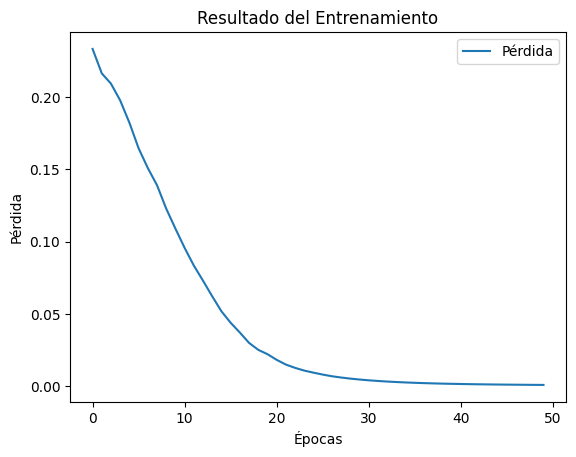

Pesos de la capa oculta:
[[ 2.029788  -2.6433873]
 [-2.0635896  2.6070886]]

Bias de la capa oculta:
[-0.0014752  -0.01825913]

Pesos de la capa de salida:
[[3.5889068]
 [2.786343 ]]

Bias de la capa de salida:
[-3.190093]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step

Predicción:
[[0.03954025]
 [0.9824203 ]
 [0.9835256 ]
 [0.03954025]]

Entradas:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Salidas esperadas:
[[0.]
 [1.]
 [1.]
 [0.]]


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

x_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype="float32")
y_train = np.array([[0], [1], [1], [0]], dtype="float32")
model = keras.Sequential()
model.add(layers.Dense(2, input_dim=2, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss="mean_squared_error",
    metrics=["accuracy"]
)

fit_history = model.fit(x_train, y_train, epochs=50, batch_size=4)
loss_curve = fit_history.history["loss"]
plt.plot(loss_curve, label="Pérdida")
plt.legend()
plt.title("Resultado del Entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.show()

weights_HL, biases_HL = model.layers[0].get_weights()
weights_OL, biases_OL = model.layers[1].get_weights()
print("Pesos de la capa oculta:")
print(weights_HL)
print("\nBias de la capa oculta:")
print(biases_HL)
print("\nPesos de la capa de salida:")
print(weights_OL)
print("\nBias de la capa de salida:")
print(biases_OL)
prediccion = model.predict(x_train)
print("\nPredicción:")
print(prediccion)
print("\nEntradas:")
print(x_train)
print("\nSalidas esperadas:")
print(y_train)

## 2. Clasificación supervisada con dataset Iris

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Cargar dataset real de flores Iris
iris = load_iris()
X, y = iris.data, iris.target

# 2. Separar datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Entrenar modelo supervisado KNN
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# 4. Evaluar el modelo
y_pred = model.predict(X_test)

print("Exactitud del modelo:", accuracy_score(y_test, y_pred))

# 5. Predicción con nuevos datos
nueva_flor = [[5.1, 3.5, 1.4, 0.2]]
prediccion = model.predict(nueva_flor)

print("Predicción para la flor nueva:", iris.target_names[prediccion][0])


Exactitud del modelo: 1.0
Predicción para la flor nueva: setosa


## 3. Clustering con KMeans: aprendizaje no supervisado

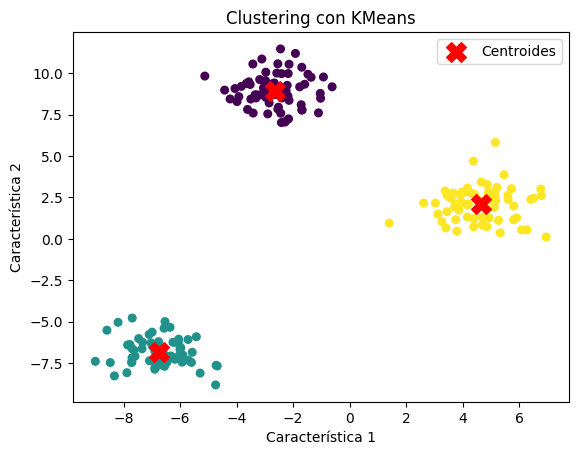

In [4]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Crear datos artificiales
X, _ = make_blobs(n_samples=200, centers=3, random_state=42)

# 2. Entrenar modelo no supervisado
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

# 3. Visualizar resultados
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="viridis", s=30)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Centroides"
)

plt.title("Clustering con KMeans")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend()
plt.show()


## 4. Red neuronal simple: Backpropagation con XOR

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# 1. Datos de entrenamiento para el problema XOR
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# 2. Crear red neuronal
model = Sequential([
    Dense(4, activation="relu", input_shape=(2,)),  # Capa oculta
    Dense(1, activation="sigmoid")                  # Capa de salida
])

# 3. Compilar el modelo
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 4. Entrenar el modelo
model.fit(X, y, epochs=500, verbose=0)

# 5. Evaluar predicciones
print("Predicciones XOR:")
print(X, "\n", model.predict(X).round())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Predicciones XOR:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[0 0]
 [0 1]
 [1 0]
 [1 1]] 
 [[0.]
 [0.]
 [1.]
 [1.]]
